# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import seaborn as sns
from typing import Optional
import pandas as pd
import numpy as np
from scipy import sparse
from anndata import AnnData
import scanpy as sc
import torch
from ciim.src.utils.util import bulkify_func
torch.set_float32_matmul_precision('medium')

import torch
from ciim.src.common import datasets_all


def plot_age_prediction(adata):
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))

    datasets = adata.obs['dataset'].unique()
    for dataset in datasets:
        subset = adata.obs[adata.obs['dataset'] == dataset]
        age = subset['age']
        pred = subset['predicted_age']

        r2 = r2_score(age, pred)
        rho, _ = spearmanr(age, pred)

        label = f"{dataset} (ρ={rho:.2f}, R²={r2:.2f})"
        sns.scatterplot(x=age, y=pred, s=10, ax=ax, label=label)

    # Plot diagonal reference line
    min_age = adata.obs['age'].min()
    max_age = adata.obs['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], 'r--', label="Identity")

    ax.set_xlabel("True Age")
    ax.set_ylabel("Predicted Age")
    ax.legend()
    ax.set_title("Age Prediction per Dataset")
    plt.tight_layout()
    plt.show()
def normalize(adata):
    adata.X = adata.X.todense().A if sparse.issparse(adata.X) else adata.X
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata

In [2]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ciim.src.clock.helper import align_feature_space

class age_predictor:
    def __init__(self):
        self.reg = Ridge(alpha=1.0)
    def format_data(self, adata: AnnData):
        X = adata.X
        y = adata.obs["age"].values.astype(np.float32)
        group = adata.obs["donor_age"].values
        batch = adata.obs["dataset"].values
        return X, y, group, batch
    def train(self, adata):
        X, y, _, _ = self.format_data(adata)
        self.features = adata.var_names
        self.reg.fit(X, y)
    def predict(self, adata):
        adata = align_feature_space(adata, self.features)
        X, y, group, batch = self.format_data(adata)
        y_pred = self.reg.predict(X)
        self.evaluate(y_pred, y, group, batch)

    def train_cv(self, adata):
        X, y, group, batch = self.format_data(adata)
        cv = KFold(n_splits=5, shuffle=True, random_state=0)

        y_pred_store = []
        y_true_store = []
        group_store = []
        batch_store = []

        for train_idx, test_idx in cv.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            group_test = group[test_idx]
            batch_test = batch[test_idx]

            # Standardize
            # X_train = scaler.fit_transform(X_train)
            # X_test = scaler.transform(X_test)

            self.reg.fit(X_train, y_train)
            y_pred = self.reg.predict(X_test)

            y_pred_store.append(y_pred)
            y_true_store.append(y_test)
            group_store.append(group_test)
            batch_store.append(batch_test)

        # Concatenate results
        y_pred = np.concatenate(y_pred_store)
        y_test = np.concatenate(y_true_store)
        group_all = np.concatenate(group_store)
        batch_all = np.concatenate(batch_store)
        self.evaluate(y_pred, y_test, group_all, batch_all)
    def evaluate(self, y_pred, y_test, group_all, batch_all):
        # Aggregate by group and batch
        df = pd.DataFrame({
            "y_pred": y_pred,
            "y_true": y_test,
            "group": group_all,
            "batch": batch_all
        })
        df['group'] = df['group'].astype(str)
        df['batch'] = df['batch'].astype(str)
        df_grouped = df.groupby(["group", "batch"], as_index=False).median()

        # Compute metrics
        rho, _ = spearmanr(df_grouped["y_true"], df_grouped["y_pred"])
        r2 = r2_score(df_grouped["y_true"], df_grouped["y_pred"])

        print(f"Spearman correlation (per donor): {rho:.2f}, R² (per donor): {r2:.2f}")
    
        # Plot prediction
        plt.figure(figsize=(4, 4))
        sns.scatterplot(data=df_grouped, x="y_true", y="y_pred", hue="batch", alpha=0.7)
        min_val = min(df_grouped["y_true"].min(), df_grouped["y_pred"].min())
        max_val = max(df_grouped["y_true"].max(), df_grouped["y_pred"].max())
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.xlabel("True median age (per donor)")
        plt.ylabel("Predicted median age (per donor)")
        # plt.title("Ridge regression on latent space")
        plt.legend(loc=(1, .8), frameon=False)
        # plt.tight_layout()

# EXA

In [3]:
from ciim.src.clock.NN.helper import format_data, train_datasets, data_type, cell_type, test_datasets
adata_train = format_data(train_datasets, cell_type, data_type)

[rank: 0] Global seed set to 0


In [4]:
adata_train

AnnData object with n_obs × n_vars = 7457 × 9674
    obs: 'sum_by', 'orig.ident', 'Major_CT', 'age', 'donor_id', 'sex', 'dataset', 'donor_age', 'cell_type', 'cell_count', 'disease'

In [5]:
adata_test = format_data(test_datasets, cell_type, data_type)
adata_test = align_feature_space(adata_test, adata_train.var_names)

In [6]:
if data_type=='sc':
    adata_train_bulk = bulkify_func(adata_train, covariates=['cell_type', 'donor_id', 'age'])
    adata_test_bulk = bulkify_func(adata_test, covariates=['cell_type', 'donor_id', 'age'])

    adata_train_bulk = normalize(adata_train_bulk)
    adata_test_bulk = normalize(adata_test_bulk)
else:
    adata_train_bulk = adata_train
    adata_test_bulk = adata_test

Spearman correlation (per donor): 0.80, R² (per donor): 0.33


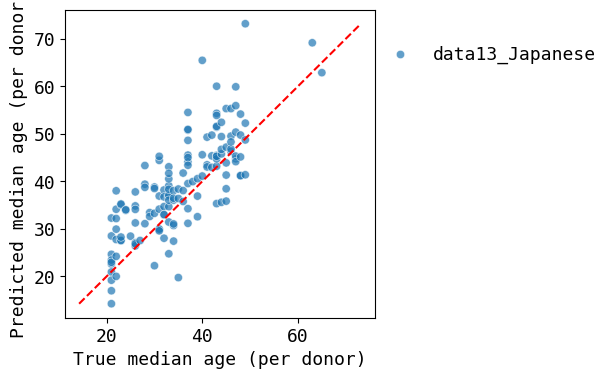

In [7]:
for cell_type in ['CD8T']:
    adata_train_bulk_t = adata_train_bulk[adata_train_bulk.obs['cell_type'] == cell_type].copy()
    adata_test_bulk_t = adata_test_bulk[adata_test_bulk.obs['cell_type'] == cell_type].copy()
    obj = age_predictor()
    obj.train(adata_train_bulk_t)
    obj.predict(adata_test_bulk_t)

In [10]:
# - original data embedding
if False:
    adata_raw = adata_train.copy()
    if data_type=='sc':
        sc.pp.normalize_total(adata_raw)
        sc.pp.log1p(adata_raw)
    # sc.pp.highly_variable_genes(adata_raw, n_top_genes=2000, subset=True)
    sc.pp.pca(adata_raw)
    wrapper_umap(adata_raw)

    sc.pl.pca(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

# Train

In [11]:
# run ../scripts/run_train_nn.sh

-TODO: 1. train with the original version. 2. reduce the epock, 3. make it 'nb'. 4. train with larger datasets 

In [12]:
import cpa
from ciim.src.common import save_dir
from ciim.src.clock.NN.helper import save_path_train, save_path_test, wrapper_setup_data, cell_type, data_type, batch_key
# save_path_train=f'{save_dir}/NN/try1' # trained with cleaned cpa, zinb, ['SLE_European', 'data12', 'data13_Korean']

model = cpa.CPA.load(dir_path=save_path_train)

INFO     File /vol/projects/jnourisa//output//NN/bulk_train/model.pt already downloaded                            


[rank: 0] Global seed set to 6977


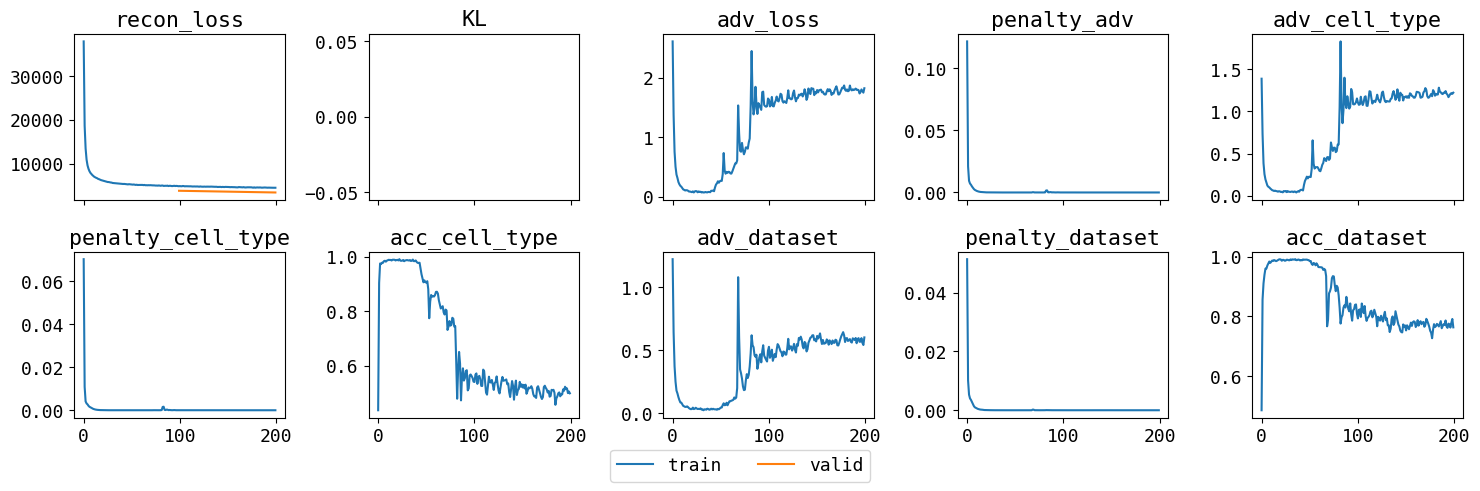

In [13]:
plot_history(model)

# Evaluate on train data

In [14]:
adata = adata_train.copy()
wrapper_setup_data(adata, data_type=data_type, batch_key=batch_key, cell_type=cell_type)
latent_dict = model.get_latent_representation(adata=adata)
adata_corrected = latent_dict['latent_corrected']

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


100%|██████████| 234/234 [00:00<00:00, 286.30it/s]


In [16]:
if False:
    wrapper_umap(latent_dict['latent_basal'])
    wrapper_umap(latent_dict['latent_corrected'])

Spearman correlation (per donor): 0.76, R² (per donor): 0.58


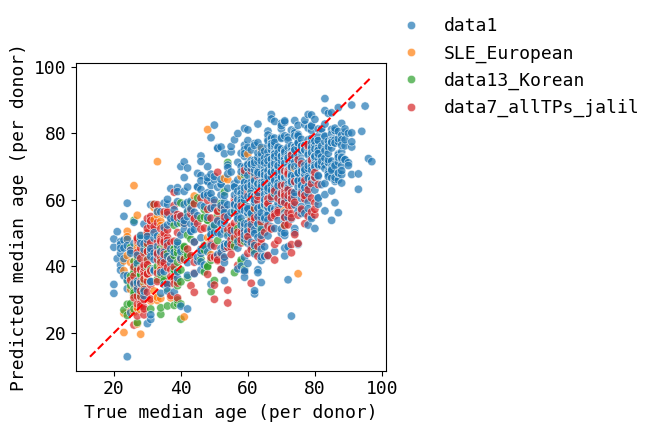

In [ ]:
if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected
for cell_type in ['CD8T']:
    adata_corrected_bulk_t = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == cell_type].copy()

    obj = age_predictor()
    obj.train_cv(adata_corrected_bulk_t)

# Train on test data

In [33]:
from ciim.src.clock.NN.helper import extend_embedding, get_params
model_params, trainer_params = get_params(data_type)

In [44]:
print("Testing mode activated.")
print('Loading model ... ')
model = cpa.CPA.load(dir_path=save_path_train)
assert len(test_datasets)==1, "Testing mode requires exactly one test dataset."
print('Loading training data ... ')
adata_train = model.adata
print('Loading test data ... ')
adata_test = format_data(test_datasets, cell_type, data_type)
from ciim.src.clock.helper import align_feature_space
adata_test = align_feature_space(adata_test, adata_train.var_names)


Testing mode activated.
Loading model ... 
INFO     File /vol/projects/jnourisa//output//NN/bulk_train/model.pt already downloaded                            


[rank: 0] Global seed set to 6977


Loading training data ... 
Loading test data ... 


In [45]:
model.setup_anndata_test(adata_test, is_count_data=True if data_type == 'sc' else False)
print('Extending embedding for test dataset ... ')
extend_embedding(model=model, new_dataset=test_datasets[0], covariate=batch_key)
print(model.covars_encoder)


Extending embedding for test dataset ... 
encoder.network.fc_layers.Layer 0.0.weight: trainable
encoder.network.fc_layers.Layer 0.0.bias: trainable
encoder.network.fc_layers.Layer 0.1.weight: trainable
encoder.network.fc_layers.Layer 0.1.bias: trainable
encoder.network.fc_layers.Layer 1.0.weight: trainable
encoder.network.fc_layers.Layer 1.0.bias: trainable
encoder.network.fc_layers.Layer 1.1.weight: trainable
encoder.network.fc_layers.Layer 1.1.bias: trainable
encoder.z.weight: trainable
encoder.z.bias: trainable
decoder.encoder.fc_layers.Layer 0.0.weight: trainable
decoder.encoder.fc_layers.Layer 0.0.bias: trainable
decoder.encoder.fc_layers.Layer 1.0.weight: trainable
decoder.encoder.fc_layers.Layer 1.0.bias: trainable
decoder.mean_encoder.weight: trainable
decoder.mean_encoder.bias: trainable
decoder.var_encoder.weight: trainable
decoder.var_encoder.bias: trainable
covars_embeddings.cell_type.weight: trainable
covars_embeddings.dataset.weight: trainable
{'cell_type': {'B': 0, 'CD4T

In [30]:
model._register_manager_for_instance(
                model.adata_manager.transfer_fields(adata_test, extend_categories=True)
        )

In [46]:
model.train(max_epochs=200,
        initial_training = False,
        use_gpu=True,
        batch_size=128,
        plan_kwargs=trainer_params,
        early_stopping_patience=5,
        check_val_every_n_epoch=100,
        save_path=save_path_test,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 100/200:  50%|█████     | 100/200 [00:59<00:59,  1.68it/s, v_num=1, recon=4.27e+3, adv_loss=nan, acc_cell_type=nan, acc_dataset=nan, val_recon=3.23e+3, val_KL=nan]


In [23]:
# ae_params[0].shape

In [37]:
# ae_params = list(filter(lambda p: p.requires_grad, model.module.encoder.parameters())) + \
#                     list(filter(lambda p: p.requires_grad, model.module.decoder.parameters())) + \
#                     list(filter(lambda p: p.requires_grad, model.module.covars_embeddings.parameters()))
# from torch.optim.lr_scheduler import StepLR
# optim = torch.optim.Adam(
#             ae_params,
#             lr=5e-4,
#             weight_decay=1e-6)
# model.test_optimizer = optim
# model.scheduler = StepLR(optim, step_size=45, gamma=0.9)



In [38]:
# adata_test

AnnData object with n_obs × n_vars = 147 × 9674
    obs: 'sum_by', 'Major_CT', 'dataset', 'cell_type', 'batch_info', 'race', 'age', 'donor_id', 'orig.ident', 'donor_age', 'sex', 'cell_count', 'disease', 'CPA_cat', '_scvi_cell_type', '_scvi_dataset', '_scvi_CPA_cat'
    var: 'gene_symbols'
    uns: '_scvi_uuid', '_scvi_manager_uuid'

In [ ]:
# import torch
# from torch.nn import MSELoss
# from tqdm import tqdm

# # Define loss
# recon_loss_fn = MSELoss()  # Or use something more appropriate for your data

# # Train loop
# n_epochs = 100
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)

# for epoch in range(n_epochs):
#     model.train()
#     epoch_loss = 0
#     for batch in tqdm(train_dataloader):
#         x = batch["input"].to(device)  # Adjust if your dataloader returns something else

#         optim.zero_grad()
#         x_recon = model(x)
#         loss = recon_loss_fn(x_recon, x)
#         loss.backward()
#         optim.step()

#         epoch_loss += loss.item()

#     scheduler.step()
#     print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")

False


NameError: name 'aaa' is not defined

In [94]:
df = model.epoch_history
metric_cols = [col for col in df.columns if col not in ['epoch', 'mode']]
n_metrics = len(metric_cols)
df

,recon_loss,KL,adv_loss,penalty_adv,adv_cell_type,penalty_cell_type,acc_cell_type,adv_dataset,penalty_dataset,acc_dataset,epoch,mode
0,6986.190890,NaN,3.299486,NaN,1.714437,NaN,0.193649,1.585049,NaN,0.231216,0,train
1,7133.704369,NaN,3.316411,NaN,1.722626,NaN,0.191859,1.593785,NaN,0.228142,1,train
2,7127.167554,NaN,3.305014,NaN,1.715715,NaN,0.199019,1.589299,NaN,0.229742,2,train
3,7200.404214,NaN,3.290987,NaN,1.707065,NaN,0.206178,1.583922,NaN,0.244104,3,train
4,7382.559533,NaN,3.311076,NaN,1.719325,NaN,0.193628,1.591750,NaN,0.231932,4,train
5,7385.924040,NaN,3.306179,NaN,1.718922,NaN,0.195207,1.587257,NaN,0.229405,5,train
6,7485.553600,NaN,3.309318,NaN,1.718808,NaN,0.198492,1.590510,NaN,0.232964,6,train
7,7577.069898,NaN,3.315270,NaN,1.722559,NaN,0.202177,1.592711,NaN,0.231890,7,train
8,7605.339438,NaN,3.307686,NaN,1.719595,NaN,0.192659,1.588091,NaN,0.233701,8,train
9,7743.732993,NaN,3.307091,NaN,1.712712,NaN,0.198850,1.594379,NaN,0.231974,9,train


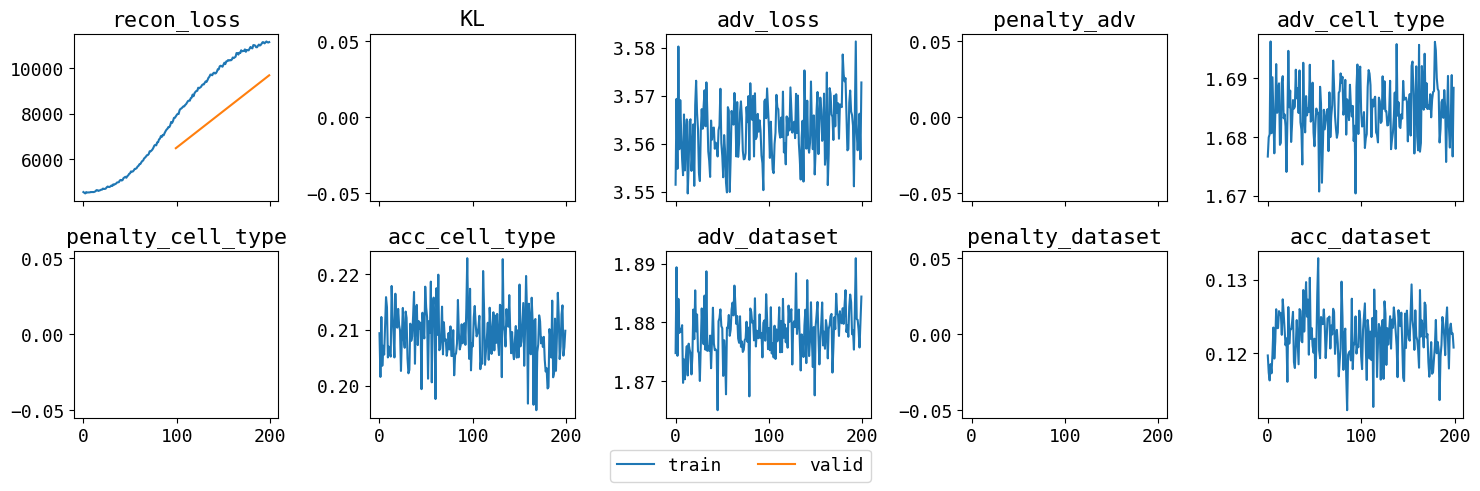

In [75]:
plot_history(model)

# Evaluate on test data

In [48]:
model_test = cpa.CPA.load(dir_path=save_path_test)

INFO     File /vol/projects/jnourisa//output//NN/bulk_test/model.pt already downloaded                             


[rank: 0] Global seed set to 6977


In [49]:
model_test.covars_encoder

{'cell_type': {'B': 0, 'CD4T': 1, 'CD8T': 2, 'MONO': 3, 'NK': 4},
 'dataset': {'SLE_European': 0,
  'data1': 1,
  'data13_Korean': 2,
  'data7_allTPs_jalil': 3,
  'data13_Japanese': 4}}

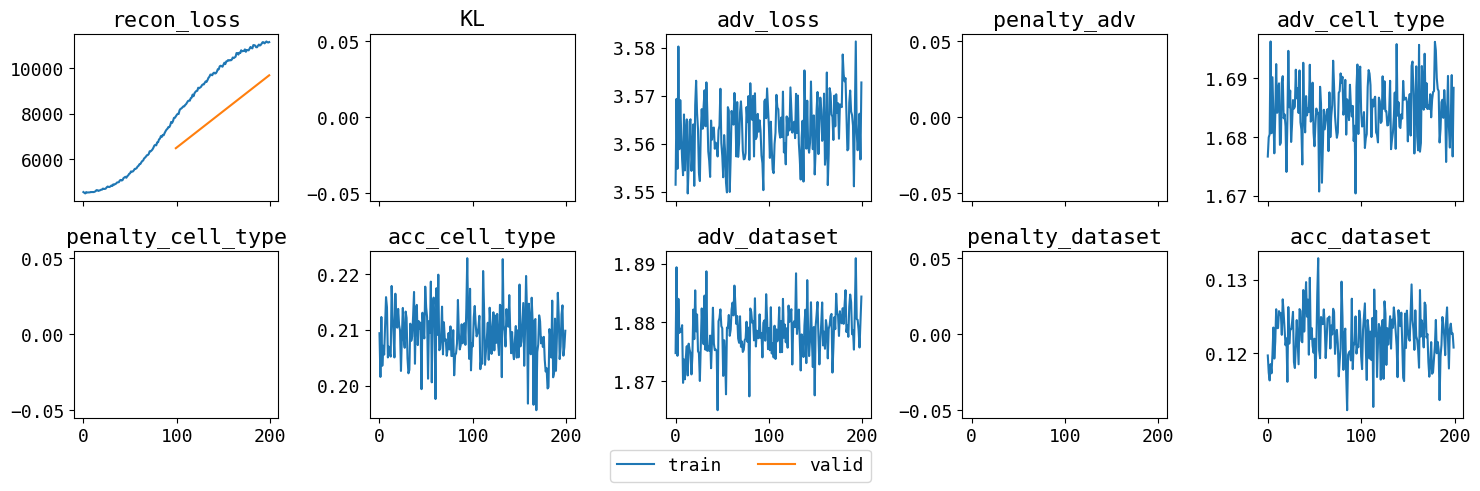

In [50]:
plot_history(model_test)

In [51]:
import anndata as ad
adata_all = ad.concat([adata_train, adata_test], axis=0)
wrapper_setup_data(adata_all, data_type=data_type, batch_key=batch_key, cell_type=cell_type)
latent_dict = model_test.get_latent_representation(adata=adata_all, extend_categories=True)
adata_corrected = latent_dict['latent_corrected']

100%|██████████| 256/256 [00:01<00:00, 213.76it/s]


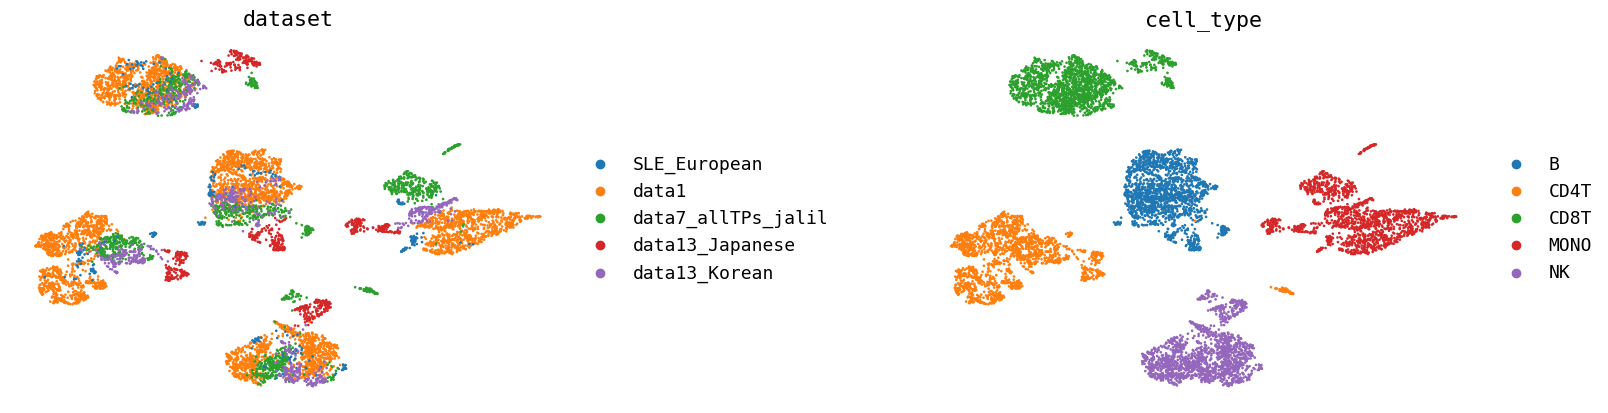

In [52]:
wrapper_umap(adata_corrected)

Spearman correlation (per donor): 0.58, R² (per donor): -0.25


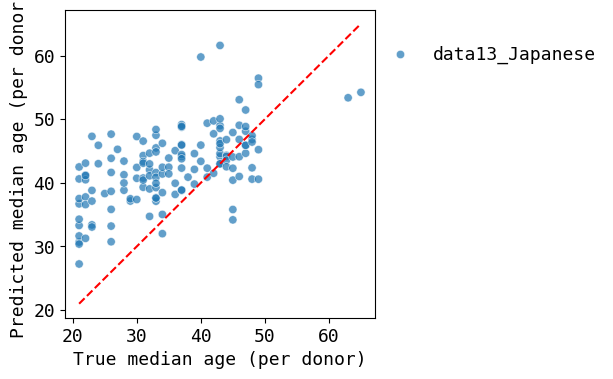

In [55]:
if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train(adata_corrected_train)
obj.predict(adata_corrected_test)